# Pairwise Consistency Model — Unified Physical-Diffusion Timeline (GP / SPDE)

Adapts the dynamical-systems consistency model to SPDE Gaussian Process data  
using the unified diffusion-physical timeline theory.

## 📋 TODO / Known Issues

### ✅ Done
- [x] **GT-only consistency target** (v3): replaced teacher EMA target with direct GT interpolation — fixes student/teacher variance explosion
- [x] **Observation fitting loss** (`λ_obs = 0.1`): pulls model toward known obs at each physical step
- [x] **Unified timeline**: single $t \in [0,1]$ variable; $t_\mathrm{IC} = 1/C$ separates spin-up and physical regime
- [x] **Sampling trajectory visualisation**: `phys_indices_list` correctly extracts physical frames from the transport process
- [x] **2-row physical frames plot**: model output vs GT on shared color scale for direct visual comparison
- [x] **Temporal obs weight conditioning** (v5): UNet now receives `w_obs(t)` — $C$ extra channels encoding the interpolation weights of obs frames at the current diffusion time. Consistent by design with the GT target construction in `_make_regime_input`. Fixes the problem where the model had no way to know which obs channel was "local" to the current $t$, causing it to output the same obs-trace pattern on all physical frames.

### 🔍 Active Observations
- [ ] **v5 training in progress**: monitor whether obs-trace leakage disappears across physical frames now that `w_obs(t)` provides explicit temporal correspondence

### ⏳ To Investigate
- [ ] **Diffusion time schedule mismatch**: verify that $\sigma(t_\mathrm{IC})$ (Karras spin-up) matches the interpolation noise level at $t_\mathrm{IC}$ in the physical regime
- [ ] **Spin-up boundary calibration**: inspect variance collapse plot — does std at `spinup_end` match GT std?
- [ ] **More training epochs / larger dataset**: model is trained on a small SPDE dataset; may need more steps or data augmentation
- [ ] **`num_timesteps` schedule**: does the Karras schedule allocate enough steps near $t_\mathrm{IC}$?


## 📖 Theory — Simplified Physical-Diffusion Consistency

Inference is performed along a single continuous variable $t \in [0,1]$ (the *diffusion time*).  
A transition point $t_\mathrm{IC} = 1/C$ (where $C$ = `window_size`) separates two regimes:

| Regime | Interval | Role |
|--------|----------|------|
| **Spin-up (diffusion)** | $[0,\,t_\mathrm{IC}]$ | Denoising toward the initial physical condition $\mathbf{x}_0$ |
| **Physical** | $[t_\mathrm{IC},\,1]$ | Trajectory supervised by physical states $\{\mathbf{x}_k\}$ |

### Input construction — $x^{(t)}$

- **Spin-up** ($t \le t_\mathrm{IC}$): noisy initial condition $\mathbf{x}^{(t)} = \mathbf{x}_0 + \sigma(t)\,\mathbf{z}$, with $\sigma(t)$ following the Karras schedule.  
- **Physical** ($t > t_\mathrm{IC}$): deterministic linear interpolation between adjacent physical frames:  
$$\mathbf{x}^{(t)} = (1-\lambda)\,\mathbf{x}_{k} + \lambda\,\mathbf{x}_{k+1}, \quad \lambda = \frac{t - t_k}{t_{k+1}-t_k}, \quad t_k = \frac{k}{C-1}(1-t_\mathrm{IC}) + t_\mathrm{IC}.$$

### Training — single GT target (simplified)

For all pairs $(t_\mathrm{int}, t_\mathrm{next})$ (both regimes, including cross-boundary):

$$\mathcal{L}_\mathrm{consistency} = \bigl\| f_\theta\!\left(\mathbf{x}^{(t_\mathrm{int})}, t_\mathrm{int}, t_\mathrm{next}, \mathbf{y}\right) - \mathbf{x}^{(t_\mathrm{next})}_\mathrm{GT} \bigr\|^2,$$

where $\mathbf{x}^{(t_\mathrm{next})}_\mathrm{GT}$ is the ground-truth interpolated state (via `_make_regime_input`).  
**No teacher EMA** needed — the GT anchor prevents student/teacher co-drift that caused variance explosion.

### Observation fitting loss (regularisation)

For each physical time step $k$ with available observations $\mathbf{y}_k$, a secondary loss pulls the model output toward the known measurements:

$$\mathcal{L}_\mathrm{obs} = \frac{1}{C} \sum_{k=0}^{C-1} \frac{\bigl\| \bigl(f_\theta(\mathbf{x}_k, t_k, t_0, \mathbf{y}) - \mathbf{x}_k\bigr) \odot \mathbf{m}_k \bigr\|^2}{\|\mathbf{m}_k\|_1 + \epsilon},$$

where $\mathbf{m}_k$ is the binary observation mask for time $k$.

### Total loss

$$\mathcal{L} = \mathcal{L}_\mathrm{consistency} + \lambda_\mathrm{obs}\,\mathcal{L}_\mathrm{obs}.$$

### Conditioning

$f_\theta$ is conditioned on the *full* observation window $\mathbf{y} = \{\mathbf{y}_0,\dots,\mathbf{y}_{C-1}\}$ (smoothing / 4DVar analogy).

## 🛠️ Setup

### GPU Check

In [1]:
!nvidia-smi

Mon Jun  8 17:02:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 555.42.02              Driver Version: 555.42.02      CUDA Version: 12.5     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A40                     Off |   00000000:4A:00.0 Off |                    0 |
|  0%   26C    P8             30W /  300W |      14MiB /  46068MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
%env CUDA_VISIBLE_DEVICES=3

env: CUDA_VISIBLE_DEVICES=3


### Imports

In [3]:
import json
import math
import os
import glob
from dataclasses import asdict, dataclass
from typing import Any, Callable, List, Optional, Tuple, Union

import numpy as np
import xarray as xr
import pandas as pd
import torch
from einops import rearrange
from einops.layers.torch import Rearrange
import pytorch_lightning as pl
from pytorch_lightning import LightningModule, Trainer, seed_everything
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint
from pytorch_lightning.loggers import TensorBoardLogger
from matplotlib import pyplot as plt
from torch import Tensor, nn
from torch.nn import functional as F
from torchinfo import summary

import sys
sys.path.append('../..')    # -> consistency/
sys.path.append('../../..')  # -> 4dvarnet-starter-devs/

from consistency_models.consistency_models_DynCM import (
    ConsistencyTrainingDynamicalSystems,
    ConsistencySamplingAndEditingDynamicalSystems,
    model_dynamical_systems_forward_wrapper,
    compute_sigma,
)
from consistency_models.consistency_models_CM import (
    ema_decay_rate_schedule,
)
from consistency_models.utils import update_ema_model_

## 🧠 Implementation

### DataModule — SPDE Diffusion Dataset

$N = $ `window_size` physical time steps.  
The transition point is $t_\mathrm{IC} = 1/N$ (one Karras step for spin-up, $N-1$ for physical evolution).

In [4]:
from src.data_notebook_spde import SPDEDataModule

SPDE_PATH = "/data/users/maxb/4dvarnet-starter-devs/SPDE/SPDE_diffusion_dataset_1.nc"

ds_inspect = xr.open_dataset(SPDE_PATH)
print(ds_inspect)
print("\nVariables:")
for v in ds_inspect.data_vars:
    print(f"  {v}: {ds_inspect[v].dims}  shape={ds_inspect[v].shape}  dtype={ds_inspect[v].dtype}")
ds_inspect.close()

<xarray.Dataset> Size: 79MB
Dimensions:    (time: 300, lat: 128, lon: 128)
Coordinates:
  * lon        (lon) int64 1kB 0 1 2 3 4 5 6 7 ... 121 122 123 124 125 126 127
  * lat        (lat) int64 1kB 0 1 2 3 4 5 6 7 ... 121 122 123 124 125 126 127
  * time       (time) int64 2kB 0 1 2 3 4 5 6 7 ... 293 294 295 296 297 298 299
Data variables:
    x          (time, lat, lon) float32 20MB ...
    y          (time, lat, lon) float32 20MB ...
    OI         (time, lat, lon) float64 39MB ...
    H11        (lat, lon) float32 66kB ...
    H22        (lat, lon) float32 66kB ...
    H12        (lat, lon) float32 66kB ...
    Time       (time) int64 2kB ...
    longitude  (lon) int64 1kB ...
    latitude   (lat) int64 1kB ...
Attributes:
    description:  SPDE-based diffusion GP

Variables:
  x: ('time', 'lat', 'lon')  shape=(300, 128, 128)  dtype=float32
  y: ('time', 'lat', 'lon')  shape=(300, 128, 128)  dtype=float32
  OI: ('time', 'lat', 'lon')  shape=(300, 128, 128)  dtype=float64
  H11: ('la

[SPDEDataModule] T=300, window=5, stride=1 → 296 windows: train=207, val=44, test=45
[SPDEDataModule] Norm stats (mean, std): (-0.00018237734911963344, 0.249156191945076)
window_size C      = 5
t_IC (transition)  = 0.2000  (= 1/C)
Spatial size       = 128 x 128
TrainingItem: input (y) (5, 128, 128)  tgt (x) (5, 128, 128)
window_size C      = 5
t_IC (transition)  = 0.2000  (= 1/C)
Spatial size       = 128 x 128
TrainingItem: input (y) (5, 128, 128)  tgt (x) (5, 128, 128)


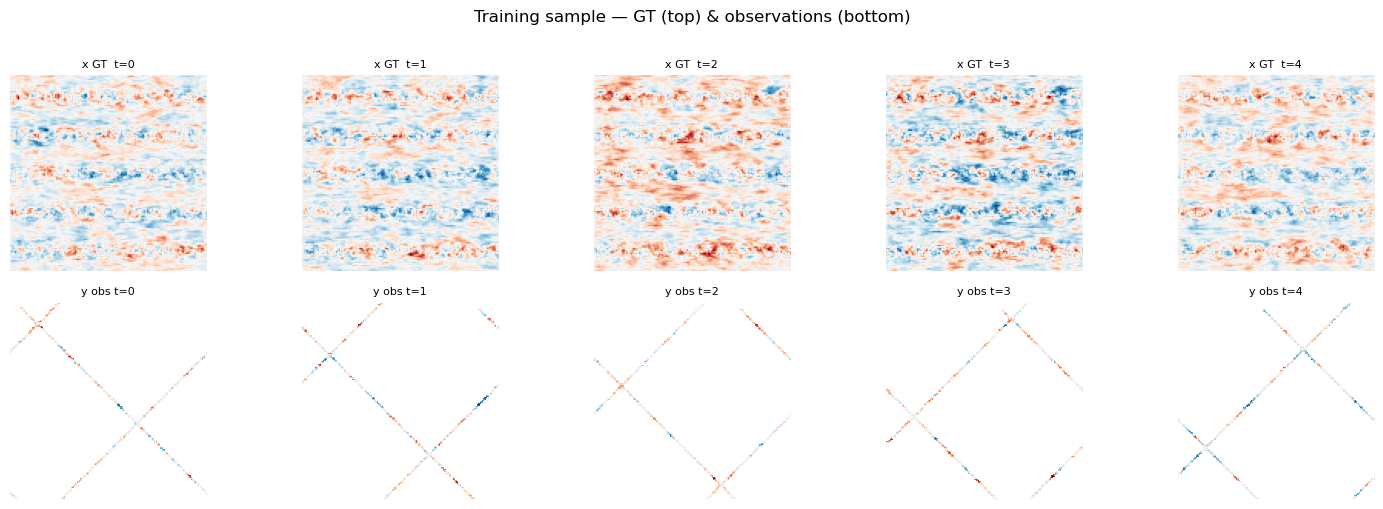

In [5]:
datamodule = SPDEDataModule(
    path=SPDE_PATH,
    window_size=5,
    stride=1,
    train_ratio=0.7,
    val_ratio=0.15,
    dl_kw={"batch_size": 1, "num_workers": 1},
)
datamodule.setup()

sample = datamodule.train_ds[0]
C  = datamodule.window_size
H, W = sample.tgt.shape[-2], sample.tgt.shape[-1]
t_IC = 1.0 / C   # transition point between spin-up and physical regime

print(f"window_size C      = {C}")
print(f"t_IC (transition)  = {t_IC:.4f}  (= 1/C)")
print(f"Spatial size       = {H} x {W}")
print(f"TrainingItem: input (y) {sample.input.shape}  tgt (x) {sample.tgt.shape}")

fig, axes = plt.subplots(2, C, figsize=(3 * C, 5))
for t_idx in range(C):
    axes[0, t_idx].imshow(sample.tgt[t_idx],   origin="lower", cmap="RdBu_r")
    axes[0, t_idx].set_title(f"x GT  t={t_idx}", fontsize=8)
    axes[0, t_idx].axis("off")
    axes[1, t_idx].imshow(sample.input[t_idx], origin="lower", cmap="RdBu_r")
    axes[1, t_idx].set_title(f"y obs t={t_idx}", fontsize=8)
    axes[1, t_idx].axis("off")
plt.suptitle("Training sample — GT (top) & observations (bottom)", y=1.01)
plt.tight_layout()
plt.show()

### UNet Building Blocks

The UNet takes:
- **x**: `(B, 1, H, W)` — current state at diffusion time $t$ (single physical field)
- **y**: `(B, C, H, W)` — full observation window (all $N$ time steps) — `NaN` = unobserved
- **mask**: `(B, C, H, W)` — binary mask derived from `y`
- **t, t'**: `(B,)` — current and target diffusion times

Total input channels = $1 + C + C = 2C + 1$.  
Output = `(B, 1, H, W)` — predicted state at $t'$.

Spatial size 100×100 is padded to the nearest multiple of 8 before the forward pass.

In [6]:
def GroupNorm(channels: int) -> nn.GroupNorm:
    return nn.GroupNorm(num_groups=min(32, channels // 4), num_channels=channels)


class SelfAttention(nn.Module):
    def __init__(self, in_channels: int, out_channels: int,
                 n_heads: int = 8, dropout: float = 0.3) -> None:
        super().__init__()
        self.dropout = dropout
        self.qkv_projection = nn.Sequential(
            GroupNorm(in_channels),
            nn.Conv2d(in_channels, 3 * in_channels, kernel_size=1, bias=False),
            Rearrange("b (i h d) x y -> i b h (x y) d", i=3, h=n_heads),
        )
        self.output_projection = nn.Sequential(
            Rearrange("b h l d -> b l (h d)"),
            nn.Linear(in_channels, out_channels, bias=False),
            Rearrange("b l d -> b d l"),
            GroupNorm(out_channels),
            nn.Dropout1d(dropout),
        )
        self.residual_projection = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x: Tensor) -> Tensor:
        q, k, v = self.qkv_projection(x).unbind(dim=0)
        output = F.scaled_dot_product_attention(
            q, k, v, dropout_p=self.dropout if self.training else 0.0, is_causal=False
        )
        output = self.output_projection(output)
        output = rearrange(output, "b c (x y) -> b c x y", x=x.shape[-2], y=x.shape[-1])
        return output + self.residual_projection(x)


class UNetBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int,
                 time_level_channels: int, dropout: float = 0.3) -> None:
        super().__init__()
        self.input_projection = nn.Sequential(
            GroupNorm(in_channels), nn.SiLU(),
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding="same"),
            nn.Dropout2d(dropout),
        )
        self.time_level_projection = nn.Sequential(
            nn.SiLU(),
            nn.Conv2d(time_level_channels, out_channels, kernel_size=1),
        )
        self.output_projection = nn.Sequential(
            GroupNorm(out_channels), nn.SiLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding="same"),
            nn.Dropout2d(dropout),
        )
        self.residual_projection = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x: Tensor, time_level: Tensor) -> Tensor:
        h = self.input_projection(x)
        h = h + self.time_level_projection(time_level)
        return self.output_projection(h) + self.residual_projection(x)


class UNetBlockWithSelfAttention(nn.Module):
    def __init__(self, in_channels: int, out_channels: int,
                 time_level_channels: int, n_heads: int = 8, dropout: float = 0.3) -> None:
        super().__init__()
        self.unet_block = UNetBlock(in_channels, out_channels, time_level_channels, dropout)
        self.self_attention = SelfAttention(out_channels, out_channels, n_heads, dropout)

    def forward(self, x: Tensor, time_level: Tensor) -> Tensor:
        return self.self_attention(self.unet_block(x, time_level))


class Downsample(nn.Module):
    def __init__(self, channels: int) -> None:
        super().__init__()
        self.projection = nn.Sequential(
            Rearrange("b c (h ph) (w pw) -> b (c ph pw) h w", ph=2, pw=2),
            nn.Conv2d(4 * channels, channels, kernel_size=1),
        )

    def forward(self, x: Tensor) -> Tensor:
        return self.projection(x)


class Upsample(nn.Module):
    def __init__(self, channels: int) -> None:
        super().__init__()
        self.projection = nn.Sequential(
            nn.Upsample(scale_factor=2.0, mode="nearest"),
            nn.Conv2d(channels, channels, kernel_size=3, padding="same"),
        )

    def forward(self, x: Tensor) -> Tensor:
        return self.projection(x)


class TimeEmbedding(nn.Module):
    """Fourier embedding for a scalar t ∈ [0,1]."""
    def __init__(self, channels: int, scale: float = 16.0) -> None:
        super().__init__()
        self.W = nn.Parameter(torch.randn(channels // 2) * scale, requires_grad=False)
        self.projection = nn.Sequential(
            nn.Linear(channels, 4 * channels),
            nn.SiLU(),
            nn.Linear(4 * channels, channels),
            Rearrange("b c -> b c () ()"),
        )

    def forward(self, x: Tensor) -> Tensor:
        h = x[:, None] * self.W[None, :] * 2 * torch.pi
        h = torch.cat([torch.sin(h), torch.cos(h)], dim=-1)
        return self.projection(h)


# ---- Spatial padding (100×100 → 104×104, multiple of 8) ----
def _pad_to_multiple(x: Tensor, multiple: int = 8) -> Tuple[Tensor, Tuple[int, int, int, int]]:
    _, _, H, W = x.shape
    pad_h = (multiple - H % multiple) % multiple
    pad_w = (multiple - W % multiple) % multiple
    padding = (0, pad_w, 0, pad_h)
    return F.pad(x, padding, mode="reflect"), padding


def _unpad(x: Tensor, padding: Tuple[int, int, int, int]) -> Tensor:
    _, pad_w, _, pad_h = padding
    H, W = x.shape[-2], x.shape[-1]
    return x[..., :H - pad_h if pad_h else H, :W - pad_w if pad_w else W]

### UNet

Input: `cat(x, y_filled, mask_y, w_obs)` → $3C+1$ channels, output: `1` channel.  
Two separate `TimeEmbedding` for $t$ and $t'$, concatenated → $2 \times$ `time_level_channels` conditioning.

**Key design** — observation weight vector $\mathbf{w}(t) \in [0,1]^C$:  
The UNet computes this vector internally from $t$, using exactly the same interpolation rule as the GT target in `_make_regime_input`:
- **Spin-up** ($t \le t_\text{IC}$): $w_0 = 1$, others 0 → only the IC obs is "local"  
- **Physical** ($t \in [t_k, t_{k+1}]$): $w_k = 1-\lambda$, $w_{k+1} = \lambda$, others 0

This weight vector is broadcast spatially and appended as $C$ additional input channels. The model thereby always knows which obs channels are temporally relevant to the current step — **no channel permutation needed**, and the correspondence is consistent with the supervised training targets.


In [7]:
@dataclass
class UNetConfig:
    # channels = C = window_size (number of physical time steps)
    channels: int = 5
    time_level_channels: int = 128
    time_level_scale: float = 16.0
    n_heads: int = 8
    top_blocks_channels: Tuple[int, ...] = (64, 64)
    top_blocks_n_blocks_per_resolution: Tuple[int, ...] = (2, 2)
    top_blocks_has_resampling: Tuple[bool, ...] = (True, True)
    top_blocks_dropout: Tuple[float, ...] = (0.0, 0.0)
    mid_blocks_channels: Tuple[int, ...] = (128, 256)
    mid_blocks_n_blocks_per_resolution: Tuple[int, ...] = (4, 4)
    mid_blocks_has_resampling: Tuple[bool, ...] = (True, False)
    mid_blocks_dropout: Tuple[float, ...] = (0.0, 0.0)


def _compute_obs_weights(t: Tensor, C: int) -> Tensor:
    """
    Compute the C-dimensional observation weight vector w(t) for each batch element.

    Uses the same temporal interpolation rule as _make_regime_input:
      - spin-up  (t ≤ t_IC = 1/C) : w = [1, 0, ..., 0]   (only IC frame relevant)
      - physical (t > t_IC)        : w_k = 1-λ, w_{k+1} = λ, others = 0
        where k = lower physical frame index and λ = fractional position in [t_k, t_{k+1}]

    Parameters
    ----------
    t : (B,) — current diffusion times, in [0, 1]
    C : int   — number of physical frames (= window_size)

    Returns
    -------
    w : (B, C) float tensor, values in [0, 1], sums to 1 per batch element
    """
    B      = t.shape[0]
    t_IC   = 1.0 / C
    device, dtype = t.device, t.dtype

    physical_steps = torch.linspace(t_IC, 1.0, C, device=device, dtype=dtype)  # (C,)

    # For each b, find the lower-bound physical frame index (vectorised)
    t_clamped = t.clamp(t_IC, 1.0).unsqueeze(1)                         # (B, 1)
    idx = torch.searchsorted(
        physical_steps.unsqueeze(0).expand(B, -1).contiguous(),
        t_clamped,
    ).squeeze(1).clamp(1, C - 1)                                         # (B,)  in [1, C-1]

    b_idx = torch.arange(B, device=device)
    dt    = (physical_steps[idx] - physical_steps[idx - 1]).clamp(min=1e-8)
    lam   = ((t.clamp(t_IC, 1.0) - physical_steps[idx - 1]) / dt).clamp(0., 1.)  # (B,)

    w = torch.zeros(B, C, device=device, dtype=dtype)
    w[b_idx, idx - 1] = 1.0 - lam
    w[b_idx, idx]     = lam

    # Override spin-up elements: only IC frame (index 0) is relevant
    spinup = (t <= t_IC)          # (B,)  bool
    w[spinup]    = 0.0
    w[spinup, 0] = 1.0

    return w  # (B, C)


class UNet(nn.Module):
    """
    UNet for the unified physical-diffusion consistency model.

    Forward signature: UNet(x, y, t, t_prime)
      x       : (B, 1,   H, W)  -- current state at diffusion time t (spin-up or physical)
      y       : (B, C,   H, W)  -- full observation window (NaN = unobserved)
      t       : (B,)            -- current diffusion time
      t_prime : (B,)            -- target diffusion time

    Input channels = 3*C + 1  (x | y_filled | mask_y | w_obs)
    Output         = 1 channel (predicted state at t')

    w_obs is the temporal interpolation weight vector w(t) ∈ [0,1]^C,
    computed internally from t using _compute_obs_weights. It tells the model
    which observation channels are "local" to the current diffusion time:
      - spin-up : w = [1, 0, ..., 0]
      - physical between frames k and k+1: w_k = 1-λ, w_{k+1} = λ, others 0
    This is consistent with the supervised GT target construction in _make_regime_input.
    """
    def __init__(self, config: UNetConfig) -> None:
        super().__init__()
        self.config = config
        C   = config.channels
        top = config.top_blocks_channels[0]

        # input: cat(x:1, y_filled:C, mask_y:C, w_obs:C) = 3C+1 channels
        self.input_projection = nn.Conv2d(3 * C + 1, top, kernel_size=3, padding="same")

        # Separate embeddings for t and t'
        self.time_embedding_t  = TimeEmbedding(config.time_level_channels, config.time_level_scale)
        self.time_embedding_tp = TimeEmbedding(config.time_level_channels, config.time_level_scale)

        self.top_encoder_blocks = self._make_encoder_blocks(
            config.top_blocks_channels + config.mid_blocks_channels[:1],
            config.top_blocks_n_blocks_per_resolution,
            config.top_blocks_has_resampling,
            config.top_blocks_dropout, self._make_top_block,
        )
        self.mid_encoder_blocks = self._make_encoder_blocks(
            config.mid_blocks_channels + config.mid_blocks_channels[-1:],
            config.mid_blocks_n_blocks_per_resolution,
            config.mid_blocks_has_resampling,
            config.mid_blocks_dropout, self._make_mid_block,
        )
        self.mid_decoder_blocks = self._make_decoder_blocks(
            config.mid_blocks_channels + config.mid_blocks_channels[-1:],
            config.mid_blocks_n_blocks_per_resolution,
            config.mid_blocks_has_resampling,
            config.mid_blocks_dropout, self._make_mid_block,
        )
        self.top_decoder_blocks = self._make_decoder_blocks(
            config.top_blocks_channels + config.mid_blocks_channels[:1],
            config.top_blocks_n_blocks_per_resolution,
            config.top_blocks_has_resampling,
            config.top_blocks_dropout, self._make_top_block,
        )
        # Output: 1 channel (single physical state)
        self.output_projection = nn.Conv2d(top, 1, kernel_size=3, padding="same")

    def forward(self, x: Tensor, y: Tensor,
                t: Tensor, t_prime: Tensor) -> Tensor:
        """
        x       : (B, 1,   H, W)
        y       : (B, C,   H, W)   -- NaN where unobserved
        t       : (B,)             -- current diffusion time
        t_prime : (B,)             -- target diffusion time
        """
        B, C, H, W = y.shape
        mask_y = (~torch.isnan(y)).to(dtype=x.dtype)
        y_fill = torch.nan_to_num(y, nan=0.0)

        # Temporal observation weights: (B, C) → broadcast to (B, C, H, W)
        # w(t) encodes which obs channels are local to the current diffusion step.
        # Uses the same interpolation rule as the supervised GT target — consistent by design.
        w_obs = _compute_obs_weights(t.to(dtype=x.dtype), C)          # (B, C)
        w_spatial = w_obs[:, :, None, None].expand(B, C, H, W)        # (B, C, H, W)

        # Concatenate along channel dim and pad to multiple of 8
        inp = torch.cat([x, y_fill, mask_y, w_spatial], dim=1)   # (B, 3C+1, H, W)
        inp, padding = _pad_to_multiple(inp, multiple=8)

        h = self.input_projection(inp)

        emb_t  = self.time_embedding_t(t)
        emb_tp = self.time_embedding_tp(t_prime)
        time_level = torch.cat([emb_t, emb_tp], dim=1)   # (B, 2*TLC, 1, 1)

        top_encoder_embeddings = []
        for block in self.top_encoder_blocks:
            if isinstance(block, UNetBlock):
                h = block(h, time_level)
                top_encoder_embeddings.append(h)
            else:
                h = block(h)

        mid_encoder_embeddings = []
        for block in self.mid_encoder_blocks:
            if isinstance(block, UNetBlockWithSelfAttention):
                h = block(h, time_level)
                mid_encoder_embeddings.append(h)
            else:
                h = block(h)

        for block in self.mid_decoder_blocks:
            if isinstance(block, UNetBlockWithSelfAttention):
                h = torch.cat((h, mid_encoder_embeddings.pop()), dim=1)
                h = block(h, time_level)
            else:
                h = block(h)

        for block in self.top_decoder_blocks:
            if isinstance(block, UNetBlock):
                h = torch.cat((h, top_encoder_embeddings.pop()), dim=1)
                h = block(h, time_level)
            else:
                h = block(h)

        out = self.output_projection(h)
        return _unpad(out, padding)

    # ---- builder helpers ----
    def _make_encoder_blocks(self, channels, n_blocks, has_resampling, dropout, block_fn):
        blocks = nn.ModuleList()
        for idx, (ic, oc) in enumerate(zip(channels[:-1], channels[1:])):
            for _ in range(n_blocks[idx]):
                blocks.append(block_fn(ic, oc, dropout[idx]))
                ic = oc
            if has_resampling[idx]:
                blocks.append(Downsample(oc))
        return blocks

    def _make_decoder_blocks(self, channels, n_blocks, has_resampling, dropout, block_fn):
        blocks = nn.ModuleList()
        for idx, (oc, ic) in enumerate(list(zip(channels[:-1], channels[1:]))[::-1]):
            if has_resampling[::-1][idx]:
                blocks.append(Upsample(ic))
            inner = []
            for _ in range(n_blocks[::-1][idx]):
                inner.append(block_fn(ic * 2, oc, dropout[::-1][idx]))
                oc = ic
            blocks.extend(inner[::-1])
        return blocks

    def _make_top_block(self, ic, oc, dropout):
        return UNetBlock(ic, oc, 2 * self.config.time_level_channels, dropout)

    def _make_mid_block(self, ic, oc, dropout):
        return UNetBlockWithSelfAttention(
            ic, oc, 2 * self.config.time_level_channels, self.config.n_heads, dropout
        )

    def save_pretrained(self, pretrained_path: str) -> None:
        os.makedirs(pretrained_path, exist_ok=True)
        with open(os.path.join(pretrained_path, "config.json"), mode="w") as f:
            json.dump(asdict(self.config), f)
        torch.save(self.state_dict(), os.path.join(pretrained_path, "model.pt"))

    @classmethod
    def from_pretrained(cls, pretrained_path: str) -> "UNet":
        with open(os.path.join(pretrained_path, "config.json"), mode="r") as f:
            config_dict = json.load(f)
        model = cls(UNetConfig(**config_dict))
        model.load_state_dict(
            torch.load(os.path.join(pretrained_path, "model.pt"), map_location="cpu")
        )
        return model


# ---- Sanity check ----
C = datamodule.window_size
_unet = UNet(UNetConfig(channels=C)).cpu()
try:
    summary(
        _unet,
        input_size=(
            (1, 1,   100, 100),  # x  (current state, 1 channel)
            (1, C,   100, 100),  # y  (full obs window, C channels)
            (1,),                # t
            (1,),                # t'
        ),
        col_names=["input_size", "output_size", "num_params"],
        verbose=0,
        device="cpu",
    )
except Exception as e:
    n_params = sum(p.numel() for p in _unet.parameters())
    print(f"[torchinfo unavailable: {e}]")
    print(f"UNet parameters: {n_params:,}")

# Quick CPU forward pass — verify shapes and w_obs values
_x = torch.randn(1, 1, 100, 100)
_y = torch.randn(1, C, 100, 100)
_y[0, :, :5, :5] = float("nan")
_t = torch.rand(1)
with torch.no_grad():
    _out = _unet(_x, _y, _t, _t)
print(f"[OK] UNet forward: x {_x.shape} + y {_y.shape} -> {_out.shape}  (3C+1={3*C+1} input channels)")
print(f"[OK] Parameters: {sum(p.numel() for p in _unet.parameters()):,}")

# Verify w_obs for a few representative times
t_IC = 1.0 / C
print(f"\nw_obs sanity check (C={C}, t_IC={t_IC:.3f}):")
for t_test in [0.0, t_IC * 0.5, t_IC, t_IC + 0.01, 0.5, 1.0]:
    w = _compute_obs_weights(torch.tensor([t_test]), C)
    print(f"  t={t_test:.3f}  →  w={w[0].tolist()}  (sum={w[0].sum().item():.3f})")


[OK] UNet forward: x torch.Size([1, 1, 100, 100]) + y torch.Size([1, 5, 100, 100]) -> torch.Size([1, 1, 100, 100])  (3C+1=16 input channels)
[OK] Parameters: 32,997,889

w_obs sanity check (C=5, t_IC=0.200):
  t=0.000  →  w=[1.0, 0.0, 0.0, 0.0, 0.0]  (sum=1.000)
  t=0.100  →  w=[1.0, 0.0, 0.0, 0.0, 0.0]  (sum=1.000)
  t=0.200  →  w=[1.0, 0.0, 0.0, 0.0, 0.0]  (sum=1.000)
  t=0.210  →  w=[0.9500000476837158, 0.04999995231628418, 0.0, 0.0, 0.0]  (sum=1.000)
  t=0.500  →  w=[0.0, 0.5000000596046448, 0.4999999403953552, 0.0, 0.0]  (sum=1.000)
  t=1.000  →  w=[0.0, 0.0, 0.0, 0.0, 1.0]  (sum=1.000)


### LightningModule

Wraps `ConsistencyTrainingDynamicalSystems` (simplified: single GT target, no teacher EMA).

**Two losses**:
1. `L_consistency` — MSE between student output and GT `_make_regime_input(t_next)`, all regimes.
2. `L_obs` — MSE between model output at physical time steps and available observations, weighted by `lambda_obs`.

The teacher EMA is still maintained (for potential future use / EMA student inference), but is no longer called during target construction.

In [8]:
@dataclass
class LitConsistencyModelConfig:
    initial_ema_decay_rate: float = 0.95
    student_model_ema_decay_rate: float = 0.99993
    lr: float = 1e-4
    betas: Tuple[float, float] = (0.9, 0.995)
    lr_scheduler_start_factor: float = 1e-5
    lr_scheduler_iters: int = 10_000
    total_training_steps: int = 10_000   # fallback only — overridden dynamically in configure_optimizers
    lambda_obs: float = 0.1              # weight for observation fitting loss
    lambda_IC:  float = 1.0              # weight for spinup IC-anchoring loss


class LitConsistencyModel(LightningModule):
    """
    Lightning wrapper for the unified physical-diffusion consistency model.

    Training uses ConsistencyTrainingDynamicalSystems with ANCHOR targets:
      - L_consistency: MSE(student_output, x_{k+1} anchor at t_next) — all regimes
      - L_obs        : MSE(f(x_k, t_k→t_{k+1}), x_{k+1}) on obs mask — λ_obs weighted

    The teacher EMA is maintained (used for spin-up regime) but NOT for physical targets.
    """
    def __init__(
        self,
        consistency_training: ConsistencyTrainingDynamicalSystems,
        student_model: UNet,
        teacher_model: UNet,
        ema_student_model: UNet,
        config: LitConsistencyModelConfig,
    ) -> None:
        super().__init__()
        self.consistency_training = consistency_training
        self.student_model        = student_model
        self.teacher_model        = teacher_model
        self.ema_student_model    = ema_student_model
        self.config               = config
        self.num_timesteps        = consistency_training.initial_timesteps
        # Will be overridden in configure_optimizers with actual training steps
        self._total_training_steps = config.total_training_steps

        for param in self.teacher_model.parameters():
            param.requires_grad = False
        for param in self.ema_student_model.parameters():
            param.requires_grad = False
        self.teacher_model     = self.teacher_model.eval()
        self.ema_student_model = self.ema_student_model.eval()

    # ------------------------------------------------------------------
    # Observation fitting loss
    # ------------------------------------------------------------------
    def _obs_loss(self, batch) -> torch.Tensor:
        """
        For each consecutive physical-frame pair (k → k+1), run the model
        with the clean anchor x_k as input at t_k targeting t_{k+1}, and
        compare to the next GT anchor x_{k+1} on the observed pixels of step k+1.

            L_obs = (1/(C-1)) * Σ_{k=0}^{C-2}
                      ||(f(x_k, t_k, t_{k+1}) - x_{k+1}) ⊙ m_{k+1}||² / (||m_{k+1}||₁ + ε)

        This is CONSISTENT with the anchor-target consistency training:
          • the consistency loss already trains f(interp(t_int), t_int, t_next) → x_{k+1}
          • this loss additionally trains f(x_k_clean, t_k, t_{k+1}) → x_{k+1} on obs pixels
          • starting from a clean anchor (not an interpolated input) adds direct supervision

        Why not use t_0 / self-mapping:
          With anchor training, f(x, t, t') → x_{anchor(t')}.  Using t'=0 asks for the
          anchor at t=0 which is the IC x_0 — useful only at k=0.  Using t'=t makes it a
          trivial identity request, which is not what the model learns.
        """
        x = batch.tgt    # (B, C, H, W)  ground truth
        y = batch.input  # (B, C, H, W)  observations (NaN = missing)
        B, C, H, W = x.shape
        device = x.device

        if C < 2:
            return torch.tensor(0.0, device=device, dtype=x.dtype)

        # NEW design: physical frame k is at diffusion time
        #   t_k = spinup_boundary * (C-1-k) / (C-1)
        # which decreases from spinup_boundary (k=0, IC) to 0 (k=C-1, last frame).
        # The model maps x_k (at t_k) → x_{k+1} (at t_{k+1} < t_k): FORWARD physical time.
        sb = self.consistency_training.spinup_boundary
        total_loss = torch.tensor(0.0, device=device, dtype=x.dtype)

        for k in range(C - 1):
            t_k      = sb * (C - 1 - k)       / max(C - 1, 1)   # decreasing: sb → step
            t_k_next = sb * (C - 2 - k)       / max(C - 1, 1)   # t_{k+1} < t_k

            t_k_full      = torch.full((B,), t_k,      device=device, dtype=x.dtype)
            t_k_next_full = torch.full((B,), t_k_next, device=device, dtype=x.dtype)

            x_k      = x[:, [k],     :, :]   # (B, 1, H, W)  clean input anchor at t_k
            x_k_next = x[:, [k + 1], :, :]   # (B, 1, H, W)  clean target anchor at t_{k+1}

            pred = model_dynamical_systems_forward_wrapper(
                self.student_model,
                x_k, y,
                t_k_full, t_k_next_full,   # t_k → t_{k+1}  (step FORWARD in physical time)
                self.consistency_training.sigma_data,
                self.consistency_training.sigma_min,
                self.consistency_training.sigma_max,
                spinup_boundary=sb,
            )

            # Mask: observed pixels at step k+1 (target frame)
            mask_kp1 = (~torch.isnan(y[:, [k + 1], :, :])).to(dtype=x.dtype)  # (B,1,H,W)
            n_obs    = mask_kp1.sum() + 1e-8

            total_loss = total_loss + ((pred - x_k_next) * mask_kp1).pow(2).sum() / n_obs

        return total_loss / (C - 1)

    # ------------------------------------------------------------------
    # Training step
    # ------------------------------------------------------------------

    def _spinup_anchor_loss(self, batch, output) -> torch.Tensor:
        """
        Spinup IC-anchoring loss: L_IC = MSE(g(IC + σ·ε, t_spin, t_IC), IC)

        Trains the model directly: from noisy IC at any spinup time t > spinup_boundary,
        produce clean IC at t_IC = spinup_boundary.

        This is the key missing term in vanilla DynCM: without it, the spinup teacher
        consistency provides no useful gradient (teacher starts random) and the model
        converges to a random fixed point instead of IC.

        Uses IC+σ·ε as input (same distribution as _make_regime_input spinup),
        so the Karras skip connection is immediately useful: c_skip·(IC+noise) is
        already 10% of the way to IC, and the model learns to cover the remaining 90%.
        """
        sb         = self.consistency_training.spinup_boundary
        sigma_max  = self.consistency_training.sigma_max
        sigma_min  = self.consistency_training.sigma_min
        sigma_data = self.consistency_training.sigma_data

        steps  = output.sigmas                            # linspace(1.0, 1e-8, N)
        k_IC   = int((steps > sb).sum().item()) - 1
        if k_IC < 0:
            return batch.tgt.new_zeros(())

        B, C, H, W = batch.tgt.shape
        device     = batch.tgt.device
        dtype      = batch.tgt.dtype
        IC         = batch.tgt[:, [0], :, :]              # (B, 1, H, W) — frame 0

        # Sample a random spinup time per batch element
        t_sp_pool  = steps[:k_IC + 1]
        sp_idx     = torch.randint(0, k_IC + 1, (B,), device=device)
        t_sp       = t_sp_pool[sp_idx]
        t_IC_vec   = torch.full((B,), sb, device=device, dtype=dtype)

        # Noisy IC input — same distribution as _make_regime_input spinup
        # (NOT pure noise: we keep the IC+sigma·noise form so the skip connection helps)
        sigma      = self.consistency_training.sigma_max
        noise      = torch.randn(B, 1, H, W, device=device, dtype=dtype)
        noisy_IC   = IC + sigma * noise                   # (B, 1, H, W)

        from consistency_models.consistency_models_DynCM import model_dynamical_systems_forward_wrapper
        pred_IC = model_dynamical_systems_forward_wrapper(
            self.student_model, noisy_IC, batch.input,
            t_sp, t_IC_vec,
            sigma_data, sigma_min, sigma_max,
            spinup_boundary=sb,
        )
        return F.mse_loss(pred_IC, IC)

    def training_step(self, batch, batch_idx: int):
        if isinstance(batch, list):
            batch = batch[0]

        output = self.consistency_training(
            self.student_model,
            self.teacher_model,
            batch.tgt,
            batch.input,
            self.global_step,
            self._total_training_steps,   # dynamic, updated in configure_optimizers
        )

        self.num_timesteps = output.num_timesteps

        # ── Consistency loss (all regimes, anchor target) ──────────────
        loss_cm = F.mse_loss(
            output.predicted_next_from_intermediate,
            output.target_next_from_current.detach(),
        )

        # ── Observation fitting loss ───────────────────────────────────
        loss_obs = self._obs_loss(batch)

        # ── IC-anchoring loss (spinup) ──────────────────────────────────
        loss_IC = self._spinup_anchor_loss(batch, output)

        loss = loss_cm + self.config.lambda_obs * loss_obs + self.config.lambda_IC * loss_IC

        if batch_idx % 20 == 0:
            grid = output.sigmas
            grid_str = (
                f"[{grid[0].item():.3f}…{grid[-1].item():.3f}]"
                if isinstance(grid, torch.Tensor) and grid.numel() > 1
                else f"N={self.num_timesteps}"
            )
            print(
                f"[Ep {self.current_epoch} | step {self.global_step}]  "
                f"N={self.num_timesteps}  "
                f"L_cm={loss_cm.item():.5f}  "
                f"L_IC={loss_IC.item():.5f}  "
                f"L_obs={loss_obs.item():.5f}  "
                f"loss={loss.item():.5f}  "
                f"t_grid={grid_str}"
            )

        self.log_dict({
            "train_loss":      loss,
            "loss_consistency": loss_cm,
            "loss_obs":        loss_obs,
            "num_timesteps":   float(self.num_timesteps),
        }, prog_bar=False)
        return loss

    def on_train_batch_end(self, outputs, batch, batch_idx: int) -> None:
        ema_rate = ema_decay_rate_schedule(
            self.num_timesteps,
            self.config.initial_ema_decay_rate,
            self.consistency_training.initial_timesteps,
        )
        update_ema_model_(self.teacher_model,     self.student_model, ema_rate)
        update_ema_model_(self.ema_student_model, self.student_model,
                          self.config.student_model_ema_decay_rate)
        self.log("ema_decay_rate", ema_rate)

    def configure_optimizers(self):
        # ── Dynamic total_training_steps ─────────────────────────────────────────
        # Use the ACTUAL number of optimizer steps that will occur (accounts for
        # accumulate_grad_batches, max_epochs, dataset size).  This ensures N grows
        # from initial_timesteps to final_timesteps over the FULL training run,
        # not just the first ~10k steps.  Without this, N saturates in epoch ~50
        # and the model can learn the trivial identity function (loss→0 but noisy
        # at inference).
        try:
            actual_steps = self.trainer.estimated_stepping_batches
            if actual_steps and int(actual_steps) > 0:
                self._total_training_steps = int(actual_steps)
                print(
                    f"[LitConsistencyModel] Dynamic total_training_steps = "
                    f"{self._total_training_steps}  "
                    f"(config fallback was {self.config.total_training_steps})"
                )
        except Exception as e:
            print(f"[LitConsistencyModel] Could not get estimated_stepping_batches ({e}), "
                  f"using config value {self.config.total_training_steps}")
            self._total_training_steps = self.config.total_training_steps

        opt = torch.optim.Adam(
            self.student_model.parameters(),
            lr=self.config.lr, betas=self.config.betas,
        )
        sched = torch.optim.lr_scheduler.LinearLR(
            opt,
            start_factor=self.config.lr_scheduler_start_factor,
            total_iters=self.config.lr_scheduler_iters,
        )
        return [opt], [{"scheduler": sched, "interval": "step", "frequency": 1}]


## 🚀 Training

### Unified timeline — time grid visualisation

Before training, let's visualise the unified time grid $\{t_0,\dots,t_N\}$ for a given
`num_timesteps` to see how the Karras grid partitions the spin-up and physical regimes.

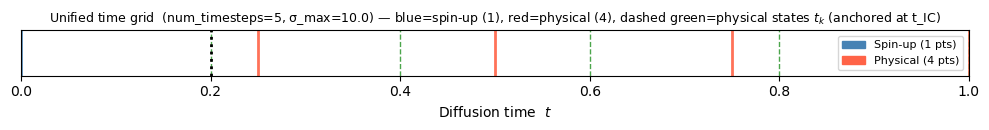

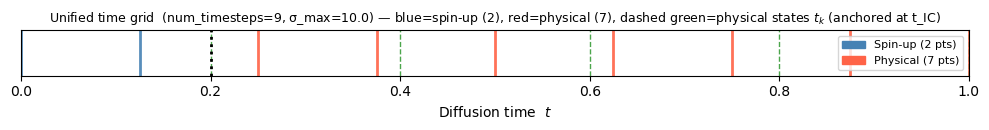

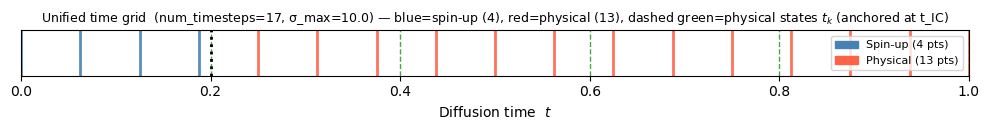

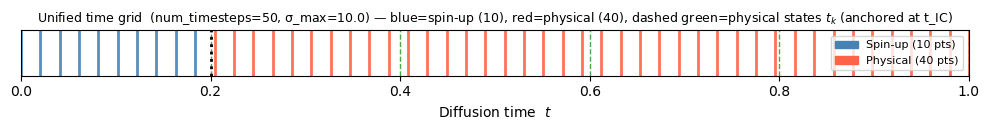

In [9]:
from consistency_models.consistency_models_DynCM import compute_sigma
from consistency_models.utils import karras_schedule

C_vis        = datamodule.window_size
t_IC_vis     = 1.0 / C_vis
# sigma_max=10 calibrated to normalised SPDE data (std≈1, SNR≤0.01).
# physical_steps now = linspace(t_IC, 1.0, C) so green dashes start at t_IC.
SIGMA_MIN    = 0.002
SIGMA_MAX    = 10.0
RHO          = 7.0

for num_t in [5, 9, 17, 50]:
    grid = karras_schedule(num_t, SIGMA_MIN, SIGMA_MAX, RHO, torch.device("cpu"), as_time=True)
    # Physical states are at linspace(t_IC, 1.0, C)  (fixed anchoring)
    physical_ts = torch.linspace(t_IC_vis, 1.0, C_vis)

    n_spinup  = (grid <= t_IC_vis).sum().item()
    n_phys    = (grid > t_IC_vis).sum().item()

    fig, ax = plt.subplots(figsize=(10, 1.4))
    for i, t_val in enumerate(grid.tolist()):
        color = "steelblue" if t_val <= t_IC_vis else "tomato"
        ax.axvline(t_val, color=color, linewidth=2, alpha=0.9)
    for t_phys in physical_ts.tolist():
        ax.axvline(t_phys, color="green", linewidth=1, linestyle="--", alpha=0.7)
    ax.axvline(t_IC_vis, color="black", linewidth=2, linestyle=":", label=f"$t_{{IC}}={t_IC_vis:.2f}$")
    ax.set_xlim(0, 1)
    ax.set_yticks([])
    ax.set_xlabel("Diffusion time  $t$")
    ax.set_title(
        f"Unified time grid  (num_timesteps={num_t}, σ_max={SIGMA_MAX}) — "
        f"blue=spin-up ({n_spinup}), red=physical ({n_phys}), "
        f"dashed green=physical states $t_k$ (anchored at t_IC)",
        fontsize=9,
    )
    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(color="steelblue", label=f"Spin-up ({n_spinup} pts)"),
        Patch(color="tomato",    label=f"Physical ({n_phys} pts)"),
    ], loc="upper right", fontsize=8)
    plt.tight_layout()
    plt.show()


### TensorBoard

In [10]:
%tensorboard --logdir=logs_CT_DynCM_spde --port 6010

UsageError: Line magic function `%tensorboard` not found.


### Training Loop

In [16]:
import shutil

RESET_TRAINING   = False # v8 = anchor targets + dynamic N schedule — start fresh
RESUME_FROM_LAST = True

LOG_DIR     = "logs_CT_DynCM_spde"
LOG_VERSION = "v8"          # v6: anchor GT targets (no identity collapse) + dynamic total_training_steps
CKPT_DIR    = os.path.join(LOG_DIR, LOG_VERSION, "checkpoints")
MODEL_PATH  = os.path.join(LOG_DIR, LOG_VERSION, "best_model")


def _is_valid_checkpoint(path: str) -> bool:
    try:
        ckpt  = torch.load(path, map_location="cpu")
        state = ckpt.get("state_dict", {})
        return all(
            not (torch.is_tensor(v) and torch.isnan(v).any())
            for v in state.values()
        )
    except Exception:
        return False


def find_resume_ckpt(ckpt_dir: str, use_last: bool = True) -> Optional[str]:
    if not os.path.isdir(ckpt_dir):
        return None
    if use_last:
        last = os.path.join(ckpt_dir, "last.ckpt")
        if os.path.isfile(last) and _is_valid_checkpoint(last):
            print(f"[OK] Resuming from: {last}")
            return last
        print("[WARN] last.ckpt missing or invalid — scanning for best valid checkpoint.")
    candidates = sorted(
        [p for p in glob.glob(os.path.join(ckpt_dir, "*.ckpt"))
         if "last" not in os.path.basename(p) and "train_loss=" in os.path.basename(p)],
        key=lambda p: float(os.path.basename(p).split("train_loss=")[-1].replace(".ckpt", "")),
    )
    for p in candidates:
        if _is_valid_checkpoint(p):
            loss_val = float(os.path.basename(p).split("train_loss=")[-1].replace(".ckpt", ""))
            print(f"[OK] Best valid checkpoint: {p}  (train_loss={loss_val:.4f})")
            return p
    print("[WARN] No valid checkpoint found — starting from scratch.")
    return None


if RESET_TRAINING:
    for d in [CKPT_DIR, MODEL_PATH]:
        if os.path.exists(d):
            shutil.rmtree(d)
            print(f"[DELETE] {d}")
    resume_ckpt = None
else:
    resume_ckpt = find_resume_ckpt(CKPT_DIR, use_last=RESUME_FROM_LAST)

# ---- Models ----
C = datamodule.window_size
student_model     = UNet(UNetConfig(channels=C))
teacher_model     = UNet(UNetConfig(channels=C))
ema_student_model = UNet(UNetConfig(channels=C))
teacher_model.load_state_dict(student_model.state_dict())
ema_student_model.load_state_dict(student_model.state_dict())

# ---- Training ----
# v6: Anchor targets to prevent identity collapse.
#   • _make_regime_input(anchor_mode=True): target = x_{k+1} clean anchor (not linear interp)
#   • configure_optimizers uses trainer.estimated_stepping_batches so N grows over the
#     FULL training run (not just the first few k steps)
#   • _obs_loss now supervises f(x_k, t_k → t_{k+1}) ≈ x_{k+1} on obs mask
#
# Identity collapse mechanism (now fixed):
#   With interp targets and large N (small dt), target ≈ input → f(x)=x minimises
#   loss perfectly → loss→0 while inference from noise produces pure noise.
ct = ConsistencyTrainingDynamicalSystems(
    sigma_min=0.002,
    sigma_max=10.0,
    rho=7.0,
    sigma_data=1.0,
    initial_timesteps=5,
    final_timesteps=50,
)

lit_cm = LitConsistencyModel(
    ct,
    student_model,
    teacher_model,
    ema_student_model,
    LitConsistencyModelConfig(
        lr_scheduler_iters=1000,
        total_training_steps=10_000,   # fallback; overridden dynamically in configure_optimizers
        lambda_obs=0.1,
    ),
)

trainer = Trainer(
    accelerator="gpu",
    max_epochs=2500,
    accumulate_grad_batches=4,
    precision="bf16-mixed",
    gradient_clip_val=1.0,
    gradient_clip_algorithm="norm",
    log_every_n_steps=1,
    logger=TensorBoardLogger(".", name=LOG_DIR, version=LOG_VERSION),
    callbacks=[
        LearningRateMonitor(logging_interval="step"),
        ModelCheckpoint(
            dirpath=CKPT_DIR,
            monitor="train_loss",
            save_top_k=3,
            save_last=True,
            filename="{epoch:03d}-{step}-{train_loss:.4f}",
        ),
    ],
)

import threading, time as _time

_keepalive_stop = threading.Event()
def _keepalive():
    p = os.path.join(os.path.expanduser("~"), ".nfs_keepalive")
    while not _keepalive_stop.wait(60):
        try:
            open(p, "w").close()
        except Exception:
            pass
_keepalive_thread = threading.Thread(target=_keepalive, daemon=True)
_keepalive_thread.start()

seed_everything(42)
trainer.fit(lit_cm, datamodule, ckpt_path=resume_ckpt)

# Save EMA model
lit_cm.ema_student_model.save_pretrained(MODEL_PATH)
print(f"[OK] EMA model saved → {MODEL_PATH}")
_keepalive_stop.set()


[OK] Resuming from: logs_CT_DynCM_spde/v8/checkpoints/last.ckpt


Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
Global seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
Global seed set to 42
Restoring states from the checkpoint path at logs_CT_DynCM_spde/v8/checkpoints/last.ckpt
Restoring states from the checkpoint path at logs_CT_DynCM_spde/v8/checkpoints/last.ckpt


[SPDEDataModule] T=300, window=5, stride=1 → 296 windows: train=207, val=44, test=45


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [3]
Loading `train_dataloader` to estimate number of stepping batches.
Loading `train_dataloader` to estimate number of stepping batches.

  | Name              | Type | Params
-------------------------------------------
0 | student_model     | UNet | 33.0 M
1 | teacher_model     | UNet | 33.0 M
2 | ema_student_model | UNet | 33.0 M
-------------------------------------------
33.0 M    Trainable params
66.0 M    Non-trainable params
99.0 M    Total params
395.975   Total estimated model params size (MB)

  | Name              | Type | Params
-------------------------------------------
0 | student_model     | UNet | 33.0 M
1 | teacher_model     | UNet | 33.0 M
2 | ema_student_model | UNet | 33.0 M
-------------------------------------------
33.0 M    Trainable params
66.0 M    Non-trainable params
99.0 M    Total params
395.975   Total estimated model params size (MB)
Restored all states from the checkpoint at logs_CT_DynCM_spde/v8/checkpoints/last.

[LitConsistencyModel] Dynamic total_training_steps = 130000  (config fallback was 10000)


Training: 0it [00:00, ?it/s]

[Ep 266 | step 13832]  N=18  L_cm=0.04803  L_IC=0.05645  L_obs=0.01042  loss=0.10552  t_grid=[1.000…0.000]
[Ep 266 | step 13837]  N=18  L_cm=0.01631  L_IC=0.06181  L_obs=0.00912  loss=0.07904  t_grid=[1.000…0.000]
[Ep 266 | step 13837]  N=18  L_cm=0.01631  L_IC=0.06181  L_obs=0.00912  loss=0.07904  t_grid=[1.000…0.000]
[Ep 266 | step 13842]  N=18  L_cm=0.04201  L_IC=0.05792  L_obs=0.00948  loss=0.10088  t_grid=[1.000…0.000]
[Ep 266 | step 13842]  N=18  L_cm=0.04201  L_IC=0.05792  L_obs=0.00948  loss=0.10088  t_grid=[1.000…0.000]
[Ep 266 | step 13847]  N=18  L_cm=0.00681  L_IC=0.06159  L_obs=0.00997  loss=0.06940  t_grid=[1.000…0.000]
[Ep 266 | step 13847]  N=18  L_cm=0.00681  L_IC=0.06159  L_obs=0.00997  loss=0.06940  t_grid=[1.000…0.000]
[Ep 266 | step 13852]  N=18  L_cm=0.00957  L_IC=0.05816  L_obs=0.00878  loss=0.06861  t_grid=[1.000…0.000]
[Ep 266 | step 13852]  N=18  L_cm=0.00957  L_IC=0.05816  L_obs=0.00878  loss=0.06861  t_grid=[1.000…0.000]
[Ep 266 | step 13857]  N=18  L_cm=0.0

## 🎲 Sampling & Evaluation

### Checkpoint Loading

In [17]:
MODEL_PATH = os.path.join("logs_CT_DynCM_spde", "v8", "best_model")

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
dtype  = torch.bfloat16 if torch.cuda.is_available() else torch.float32

unet = UNet.from_pretrained(MODEL_PATH).eval().to(device=device, dtype=dtype)
print(f"[OK] Model loaded from: {MODEL_PATH}")
print(f"     Input channels: 3*C+1 = {3 * datamodule.window_size + 1}  (x | y_filled | mask_y | w_obs)")


[OK] Model loaded from: logs_CT_DynCM_spde/v8/best_model
     Input channels: 3*C+1 = 16  (x | y_filled | mask_y | w_obs)


### Test Batch

Global seed set to 42


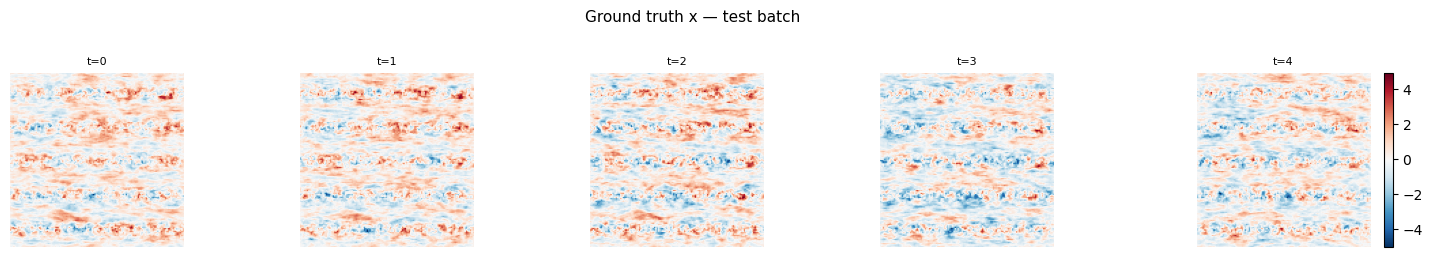

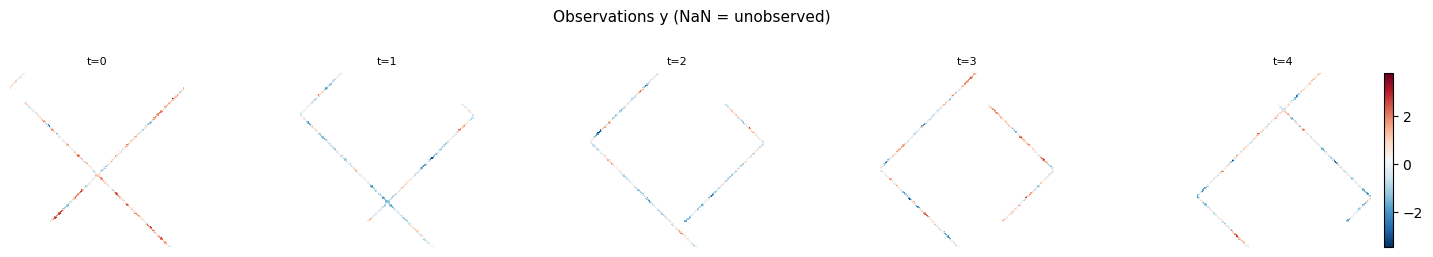

In [18]:
seed_everything(42)
batch = next(iter(datamodule.test_dataloader()))

def plot_field(arr: np.ndarray, title: str = "", vmin=None, vmax=None,
               cols: int = 5, cmap: str = "RdBu_r") -> None:
    T    = arr.shape[0]
    rows = math.ceil(T / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 2.5 * rows))
    axes = np.array(axes).ravel()
    for t in range(T):
        im = axes[t].imshow(arr[t], origin="lower", cmap=cmap, vmin=vmin, vmax=vmax)
        axes[t].set_title(f"t={t}", fontsize=8)
        axes[t].axis("off")
    for ax in axes[T:]:
        ax.axis("off")
    if title:
        fig.suptitle(title, fontsize=11, y=1.01)
    plt.colorbar(im, ax=axes[-1], fraction=0.046)
    plt.tight_layout()
    plt.show()


plot_field(batch.tgt[0].float().numpy(),   title="Ground truth x — test batch")
plot_field(batch.input[0].float().numpy(), title="Observations y (NaN = unobserved)")

### Ensemble Generation

The sampler traverses the unified time grid from $s=0$ (pure noise) to $s=1$ (clean):

| Phase | Solver time $s$ | Diffusion time $t$ | Behaviour |
|---|---|---|---|
| **Spin-up** | $[0, \text{SPINUP\_FRAC}] \approx [0, 0.3]$ | $[0.7, 1]$ | Noise → IC (frame 0) |
| **Physical** | $[\text{SPINUP\_FRAC}, 1] \approx [0.3, 1]$ | $[0, 0.7]$ | IC → frame 1 → … → frame C−1 |

- `spinup_boundary` $= 1 - \text{SPINUP\_FRAC} = 0.7$ in diffusion time coordinates.
- Physical frame $k$ is anchored at $t_k = \text{sb} \times (C-1-k)/(C-1)$, reached at $s_k = 1 - t_k$.
- With `NSTEPS = 4C+1`, the IC appears at step $\approx C+1$ (solver time $\approx 0.3$) and frames are spaced ~3 steps apart.
- The full observation window $\mathbf{y}$ conditions every step.


In [14]:
N_SAMPLES = 10
# NSTEPS = 4*C+1 gives ~C+1 spin-up steps and ~3*C physical steps.
# With SPINUP_BOUNDARY=0.7: spin-up ≈ first 30% of steps (s ∈ [0, 0.3]),
# physical ≈ last 70% (s ∈ [0.3, 1]).  IC appears at s ≈ 0.3 (step ~C+1).
NSTEPS = 4 * datamodule.window_size + 1

SPINUP_BOUNDARY = ct.spinup_boundary   # 0.7 — must match training

STOCHASTIC = False  # False = déterministe (consistency pure, comportement original)
                    # True  = stochastique: réinjecte Δσ·ε à chaque step spin-up
                    #         → débruitage progressif du spin-up (DDPM-like)
consistency_sampling = ConsistencySamplingAndEditingDynamicalSystems(
    sigma_min=0.002,
    sigma_max=10.0,   # match training sigma_max
    sigma_data=1.0,
    spinup_boundary=SPINUP_BOUNDARY,
    stochastic=STOCHASTIC,
)

C  = datamodule.window_size
H, W = batch.tgt.shape[-2], batch.tgt.shape[-1]
y_dev = batch.input.to(device=device, dtype=dtype)

samples         = []
samples_process = []
phys_indices_list = []

with torch.no_grad():
    for i in range(N_SAMPLES):
        noise = torch.randn((1, 1, H, W), device=device, dtype=dtype)
        result = consistency_sampling(
            unet,
            noise,
            y_dev,
            nsteps=NSTEPS,
            clip_denoised=False,
            verbose=(i == 0),
        )
        sample, sample_process, phys_idx = result
        samples.append(sample.float().cpu())
        samples_process.append(sample_process.float().cpu())
        if i == 0:
            phys_indices_list = phys_idx   # list of ints, IC-first order
        print(f"  Sample {i+1}/{N_SAMPLES} done", end="\r")

print(f"\n[OK] {N_SAMPLES} ensemble members generated  (nsteps={NSTEPS})")
print(f"Physical frame indices IC→last: {phys_indices_list}")
print(f"  → solver_times: {[f'{si/(NSTEPS-1):.2f}' for si in phys_indices_list]}")
print(f"  IC expected at s ≈ {1-SPINUP_BOUNDARY:.2f}  (step ~{round((1-SPINUP_BOUNDARY)*(NSTEPS-1))})")
print(f"\nSample shape: {samples[0].shape}")
print(f"Process shape: {samples_process[0].shape}  (nsteps, B=1, 1, H, W)")


  Sample 10/10 done
[OK] 10 ensemble members generated  (nsteps=21)
Physical frame indices IC→last: [6, 10, 13, 17, 20]
  → solver_times: ['0.30', '0.50', '0.65', '0.85', '1.00']
  IC expected at s ≈ 0.30  (step ~6)

Sample shape: torch.Size([1, 1, 128, 128])
Process shape: torch.Size([21, 1, 1, 128, 128])  (nsteps, B=1, 1, H, W)
  Sample 10/10 done
[OK] 10 ensemble members generated  (nsteps=21)
Physical frame indices IC→last: [6, 10, 13, 17, 20]
  → solver_times: ['0.30', '0.50', '0.65', '0.85', '1.00']
  IC expected at s ≈ 0.30  (step ~6)

Sample shape: torch.Size([1, 1, 128, 128])
Process shape: torch.Size([21, 1, 1, 128, 128])  (nsteps, B=1, 1, H, W)


### Transport process — sampling trajectory visualisation

Display **all diffusion steps** and then extract the **physical time steps** from the trajectory.  
The model maps noise at $t=1$ through the spin-up into the physical regime step by step.

In [ ]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np

# ── Regime fractions ───────────────────────────────────────────────────────────
SPINUP_FRAC = round(1.0 - consistency_sampling.spinup_boundary, 2)   # 0.30 (not 0.300000004)

proc  = samples_process[0]
nfr   = proc.shape[0]

def solver_time(si):
    return round(si / max(nfr - 1, 1), 2)

phys_frames    = proc[phys_indices_list, 0, 0, :, :].numpy()
phys_times_lst = [solver_time(i) for i in phys_indices_list]
gt_phys_frames = batch.tgt[0].float().numpy()
obs_frames     = np.nan_to_num(batch.input[0].float().numpy(), nan=0.0)

vmin_all, vmax_all = -2, 2

# ── Build step_indices ─────────────────────────────────────────────────────────
# 4 evenly-spaced spin-up steps (0 … phys0-1) then, for each pair of consecutive
# physical frames, interleave: [phys_k, mid_k_k+1, phys_{k+1}, ...]
phys0        = phys_indices_list[0]
N_SPINUP_COL = 4
spinup_steps = sorted({
    round(k * (phys0 - 1) / max(N_SPINUP_COL - 1, 1))
    for k in range(N_SPINUP_COL)
    if round(k * (phys0 - 1) / max(N_SPINUP_COL - 1, 1)) < phys0
})

phys_and_intermed = []
for k, pi in enumerate(phys_indices_list):
    phys_and_intermed.append(pi)
    if k < len(phys_indices_list) - 1:
        mid = int((pi + phys_indices_list[k + 1]) / 2)   # int() avoids banker's rounding
        phys_and_intermed.append(mid)

step_indices         = spinup_steps + phys_and_intermed
step_indices_display = step_indices
n_top                = len(step_indices_display)

phys_step_set = set(phys_indices_list)
spinup_cols   = [j for j, si in enumerate(step_indices_display)
                 if si not in phys_step_set and solver_time(si) <= SPINUP_FRAC]

# Physical columns — guaranteed to be exact (values are in step_indices)
phys_col = [step_indices_display.index(pi) for pi in phys_indices_list]

print(f"step_indices ({n_top} cols) = {step_indices}")
print(f"phys_col                   = {phys_col}")
print(f"spinup_cols                = {spinup_cols}")

# ── Figure layout ──────────────────────────────────────────────────────────────
# 4 rows (transport | prediction | GT | obs) + horizontal colorbar at bottom
FIG_W   = max(n_top * 1.55, 18)
FIG_H   = 11.5
PUB_FS  = 11   # publication font size for row labels
TOP_FS  = 10   # font size for diffusion-time titles in top strip

fig = plt.figure(figsize=(FIG_W, FIG_H))
gs  = fig.add_gridspec(
    4, n_top,
    height_ratios=[3, 2, 2, 2],
    hspace=0.25, wspace=0.04,
    left=0.10, right=0.98, top=0.93, bottom=0.14,
)

axes_top = [fig.add_subplot(gs[0, j]) for j in range(n_top)]
axes_mid = {k: fig.add_subplot(gs[1, col]) for k, col in enumerate(phys_col)}
axes_bot = {k: fig.add_subplot(gs[2, col]) for k, col in enumerate(phys_col)}
axes_obs = {k: fig.add_subplot(gs[3, col]) for k, col in enumerate(phys_col)}

# ── Row 0: transport strip ────────────────────────────────────────────────────
for j, si in enumerate(step_indices_display):
    ax    = axes_top[j]
    s_val = solver_time(si)
    ax.imshow(proc[si, 0, 0, :, :].numpy(), origin="lower",
              cmap="RdBu_r", vmin=vmin_all, vmax=vmax_all, interpolation="nearest")
    col_t = "steelblue" if s_val <= SPINUP_FRAC else "tomato"
    ax.set_title(f"s={s_val:.2f}", fontsize=TOP_FS, color=col_t, pad=2, fontweight="bold")
    ax.axis("off")
    if si in phys_step_set:
        for sp in ax.spines.values():
            sp.set_visible(True); sp.set_edgecolor("limegreen"); sp.set_linewidth(2.5)

# ── Rows 1–3: prediction / GT / obs (blank at intermediate columns) ───────────
C = len(phys_indices_list)
for k in range(C):
    axes_mid[k].imshow(phys_frames[k], origin="lower", cmap="RdBu_r",
                       vmin=vmin_all, vmax=vmax_all, interpolation="nearest")
    axes_mid[k].axis("off")
    for sp in axes_mid[k].spines.values():
        sp.set_visible(True); sp.set_edgecolor("limegreen"); sp.set_linewidth(2)

    axes_bot[k].imshow(gt_phys_frames[k], origin="lower", cmap="RdBu_r",
                       vmin=vmin_all, vmax=vmax_all, interpolation="nearest")
    axes_bot[k].axis("off")

    axes_obs[k].imshow(obs_frames[k], origin="lower", cmap="RdBu_r",
                       vmin=vmin_all, vmax=vmax_all, interpolation="nearest")
    axes_obs[k].axis("off")

# ── Row labels (publication-ready: black, bold, large) ───────────────────────
fig.canvas.draw()
label_x = axes_top[0].get_position().x0 - 0.012
rows_meta = [
    (axes_top[0],  "Transport\nprocess"),
    (axes_mid[0],  "DynCM\nprediction"),
    (axes_bot[0],  "Ground\ntruth"),
    (axes_obs[0],  "Observations"),
]
for ax_ref, lbl in rows_meta:
    pos = ax_ref.get_position()
    yc  = (pos.y0 + pos.y1) / 2
    fig.text(label_x, yc, lbl, va="center", ha="right",
             fontsize=PUB_FS, color="black", fontweight="bold", rotation=0,
             fontfamily="DejaVu Sans")

# ── Arrows: transport strip → prediction row ──────────────────────────────────
for k, col in enumerate(phys_col):
    sb = axes_top[col].get_position()
    db = axes_mid[k].get_position()
    xm = (sb.x0 + sb.x1) / 2
    fig.add_artist(mpatches.FancyArrowPatch(
        (xm, sb.y0 - 0.003), (xm, db.y1 + 0.003),
        transform=fig.transFigure, arrowstyle="-|>",
        color="blueviolet", mutation_scale=10, linewidth=1.5,
    ))

# ── Spin-up brace above top strip ────────────────────────────────────────────
if spinup_cols:
    p0   = axes_top[spinup_cols[0]].get_position()
    p1   = axes_top[spinup_cols[-1]].get_position()
    xL, xR = p0.x0, p1.x1
    yT   = p0.y1 + 0.016
    th   = 0.007
    for xt in [xL, xR]:
        fig.add_artist(plt.Line2D([xt, xt], [yT, yT - th],
            transform=fig.transFigure, color="steelblue", linewidth=1.4, clip_on=False))
    fig.add_artist(plt.Line2D([xL, xR], [yT, yT],
        transform=fig.transFigure, color="steelblue", linewidth=1.4, clip_on=False))
    fig.text((xL + xR) / 2, yT + 0.003,
             f"Spin-up  (s ≤ {SPINUP_FRAC:.2f})",
             ha="center", va="bottom", fontsize=PUB_FS - 1, color="steelblue")

# ── Horizontal colorbar at bottom ────────────────────────────────────────────
cbar_ax = fig.add_axes([0.15, 0.04, 0.70, 0.018])
sm = plt.cm.ScalarMappable(cmap="RdBu_r",
                            norm=plt.Normalize(vmin=vmin_all, vmax=vmax_all))
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Gaussian Process", fontsize=PUB_FS + 1, fontweight="bold")
cbar.ax.tick_params(labelsize=PUB_FS - 1)

plt.show()

# ── Variance collapse ─────────────────────────────────────────────────────────
step_stds = np.array([proc[k, 0, 0, :, :].numpy().std() for k in range(nfr)])
gt_std    = batch.tgt[0].float().numpy().std()
fig2, ax2 = plt.subplots(figsize=(8, 3))
s_vals = np.array([solver_time(k) for k in range(nfr)])
ax2.plot(s_vals, step_stds, marker="o", color="dimgray", label="Member 0")
ax2.axhline(gt_std, color="green", linestyle="--", label=f"GT std = {gt_std:.3f}")
ax2.axvspan(0.0, SPINUP_FRAC, alpha=0.10, color="steelblue",
            label=f"Spin-up (s ≤ {SPINUP_FRAC:.2f})")
ax2.axvspan(SPINUP_FRAC, 1.0, alpha=0.10, color="tomato", label="Physical regime")
for pi, pt in zip(phys_indices_list, phys_times_lst):
    ax2.axvline(pt, color="limegreen", alpha=0.6, linewidth=1)
ax2.set_xlabel("Solver time  s  (0 = pure noise, 1 = clean)", fontsize=PUB_FS)
ax2.set_ylabel("Spatial std", fontsize=PUB_FS)
ax2.set_title("Variance collapse — spin-up → physical", fontsize=PUB_FS + 1)
ax2.legend(fontsize=PUB_FS - 1)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Std step 0 (noise): {step_stds[0]:.4f}   Std last step: {step_stds[-1]:.4f}   GT std: {gt_std:.4f}")

### Ensemble — mean, std, error maps

In [ ]:

# Stack samples using the computed physical indices (IC-first order)
def extract_physical_trajectory(proc_tensor: torch.Tensor, idx_list) -> torch.Tensor:
    """proc_tensor: (nsteps+1, 1, 1, H, W) -> (C, H, W)"""
    return proc_tensor[idx_list, 0, 0, :, :]   # (C, H, W)


traj_list  = [extract_physical_trajectory(p, phys_indices_list) for p in samples_process]
traj_stack = torch.stack(traj_list, dim=0).numpy()   # (N, C, H, W)

ens_mean_traj = traj_stack.mean(axis=0)   # (C, H, W)
ens_std_traj  = traj_stack.std(axis=0)    # (C, H, W)
gt_np         = batch.tgt[0].float().numpy()   # (C, H, W)

plot_field(gt_np,                                       title="Ground truth x")
plot_field(ens_mean_traj,                               title="Ensemble mean  (physical trajectory, corrected indices)")
plot_field(ens_std_traj,      vmin=0, cmap="Reds",      title="Ensemble std   (uncertainty)")
plot_field(np.abs(ens_mean_traj - gt_np), vmin=0, cmap="Reds", title="|mean − GT|")


## 📊 Metrics

- **μ-score** = $1 - \text{RMSE}/\sigma_\text{GT}$ (higher is better)
- **RMSE** (lower is better)
- **Spread-skill ratio** (ideal ~ 1)
- **Radial PSD** — spectral comparison vs GT and OI baseline

In [ ]:
try:
    from properscoring import crps_ensemble
    HAS_PROPERSCORING = True
except ImportError:
    HAS_PROPERSCORING = False
    print("[WARN] properscoring not installed — CRPS disabled.")

m_norm, s_norm = datamodule.norm_stats()

gt_phys       = gt_np       * s_norm + m_norm
ens_mean_phys = ens_mean_traj * s_norm + m_norm
traj_phys     = traj_stack    * s_norm + m_norm   # (N, C, H, W)

# OI baseline
start_t = datamodule.test_ds.indices[0]
ws      = datamodule.window_size
oi_phys = datamodule.oi[start_t : start_t + ws].astype(np.float32)
oi_norm = (oi_phys - m_norm) / s_norm


def compute_psd_and_lambda_x(field: np.ndarray, dx: float = 1.0):
    f = field.copy()
    f[np.isnan(f)] = 0.0
    psd_sum = sum(np.abs(np.fft.fft2(f[t])) ** 2 for t in range(f.shape[0]))
    psd_avg = psd_sum / f.shape[0]
    ny, nx  = psd_avg.shape
    yy, xx  = np.meshgrid(np.arange(ny) - ny // 2, np.arange(nx) - nx // 2, indexing="ij")
    rr      = np.sqrt(xx ** 2 + yy ** 2)
    r_max   = int(np.sqrt((ny // 2) ** 2 + (nx // 2) ** 2))
    radial_psd = np.array([
        np.mean(np.fft.fftshift(psd_avg)[(rr >= r) & (rr < r + 1)])
        if np.any((rr >= r) & (rr < r + 1)) else 0.0
        for r in range(r_max)
    ])
    threshold = 0.5 * np.max(radial_psd[1:])
    idx_50    = np.where(radial_psd < threshold)[0]
    lambda_x  = (nx * dx) / idx_50[0] if len(idx_50) > 0 else np.nan
    return lambda_x, radial_psd


def metrics_vs_gt(pred, gt, label, dx=1.0):
    gt_std   = np.nanstd(gt)
    rmse_v   = np.sqrt(np.nanmean((pred - gt) ** 2))
    mu       = 1.0 - rmse_v / gt_std
    lx_gt,   psd_gt   = compute_psd_and_lambda_x(gt,   dx=dx)
    lx_pred, psd_pred = compute_psd_and_lambda_x(pred, dx=dx)
    spectral = np.corrcoef(psd_gt[:len(psd_gt) // 2], psd_pred[:len(psd_pred) // 2])[0, 1]
    return dict(Method=label, mu_score=mu, RMSE=rmse_v,
                lambda_x_GT=lx_gt, lambda_x_pred=lx_pred, spectral_corr=spectral), psd_pred, psd_gt


row_cm, psd_cm, psd_gt_rad = metrics_vs_gt(ens_mean_phys, gt_phys, "DynConsistency (mean traj)")
row_oi, psd_oi, _           = metrics_vs_gt(oi_phys,        gt_phys, "OI baseline")

rmse_cm_norm = np.sqrt(np.nanmean((ens_mean_traj - gt_np) ** 2))
rmse_oi_norm = np.sqrt(np.nanmean((oi_norm        - gt_np) ** 2))
print(f"RMSE DynConsistency (normalised): {rmse_cm_norm:.4f}")
print(f"RMSE OI             (normalised): {rmse_oi_norm:.4f}")

rmse_det = np.sqrt(np.nanmean((ens_mean_phys - gt_phys) ** 2))
spread   = np.nanmean(np.std(traj_phys, axis=0))
print(f"\nEnsemble spread (mean std) : {spread:.4f}")
print(f"RMSE (ensemble mean)       : {rmse_det:.4f}")
print(f"Spread-skill ratio         : {spread / max(rmse_det, 1e-8):.4f}  (ideal ~ 1.0)")

if HAS_PROPERSCORING:
    crps_vals = [
        crps_ensemble(gt_phys[t, i, j], traj_phys[:, t, i, j])
        for t in range(gt_phys.shape[0])
        for i in range(gt_phys.shape[1])
        for j in range(gt_phys.shape[2])
        if not np.isnan(gt_phys[t, i, j])
    ]
    print(f"CRPS mean (ensemble)       : {np.mean(crps_vals):.4f}")

df = pd.DataFrame([row_cm, row_oi]).set_index("Method")
for col in ["mu_score", "RMSE", "spectral_corr"]:
    df[col] = df[col].map("{:.4f}".format)
for col in ["lambda_x_GT", "lambda_x_pred"]:
    df[col] = df[col].map(lambda v: f"{v:.2f}" if not np.isnan(v) else "N/A")
print("\n## Performance — DynConsistency vs OI (SPDE dataset)\n")
print(df.to_markdown())
display(df)

### Radial PSD

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(psd_gt_rad, label="Ground truth",               linewidth=2)
ax.semilogy(psd_cm,      label="DynConsistency (ens. mean)", linewidth=2, linestyle="--")
ax.semilogy(psd_oi,      label="OI baseline",                linewidth=2, linestyle=":")
ax.set_xlabel("Radial wavenumber (pixels$^{-1}$)")
ax.set_ylabel("Power Spectral Density")
ax.set_title("Radial PSD — SPDE dataset (DynConsistency)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Visual Comparison — GT / OI / DynConsistency per physical time step

In [ ]:
rows_data = {
    "GT":                gt_np,
    "Obs y (NaN→0)":     np.nan_to_num(batch.input[0].float().numpy(), nan=0.0),
    "OI (norm)":         oi_norm,
    "DynCM mean traj":   ens_mean_traj,
    "DynCM std  traj":   ens_std_traj,
    "|DynCM - GT|":      np.abs(ens_mean_traj - gt_np),
    "|OI - GT|":         np.abs(oi_norm - gt_np),
}

for label, arr in rows_data.items():
    vmin_v = 0 if ("std" in label or "|" in label) else None
    cmap_v = "Reds" if ("std" in label or "|" in label) else "RdBu_r"
    plot_field(arr, title=label, vmin=vmin_v, cmap=cmap_v, cols=C)